In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PHASE_SHIFT_SAMPLES = 00 # each 1 count = 20e-6 s or ts
VOLTAGE_GAIN = 4.0 # voltage scaling factor
TEMPERATURE_SCALE = 0.01 # scaling factor
ts = 20E-6 # sampling perio 20us

In [68]:
def ReadExperiment(csvFile):
    dfTemp = pd.read_csv(
        csvFile,
        sep=",",
        names=["Unnamed 1","Info","Unnamed 2","Time","Current","Unnamed 3","Unnamed 4",
               "Unnamed 5","Unnamed 6","Time 2","Temperature","Unnamed 7","Unnamed 8",
               "Unnamed 9","Unnamed 10","Time 3","Voltage","Unnamed 11"],
        low_memory=False)
    df = dfTemp[["Time", "Current", "Temperature", "Voltage"]].copy()

    df["Voltage"] = np.roll(df["Voltage"].to_numpy(), -PHASE_SHIFT_SAMPLES)
    df["Voltage"] = df["Voltage"] / VOLTAGE_GAIN
    df["Temperature"] = df["Temperature"] / TEMPERATURE_SCALE

    return df

In [69]:
exp = ('../data/sample0/experiment0.csv')
data = ReadExperiment(exp)
data

,Time,Current,Temperature,Voltage
0,-1.00000,10.0,26.400000,0.0046
1,-0.99998,12.0,24.800001,0.0046
2,-0.99996,11.6,25.600001,0.0046
3,-0.99994,11.2,25.600001,0.0046
4,-0.99992,10.8,26.000002,0.0050
...,...,...,...,...
99995,0.99990,10.0,26.400000,0.0050
99996,0.99992,11.6,26.000002,0.0046
99997,0.99994,11.6,26.000002,0.0050
99998,0.99996,11.2,26.000002,0.0046


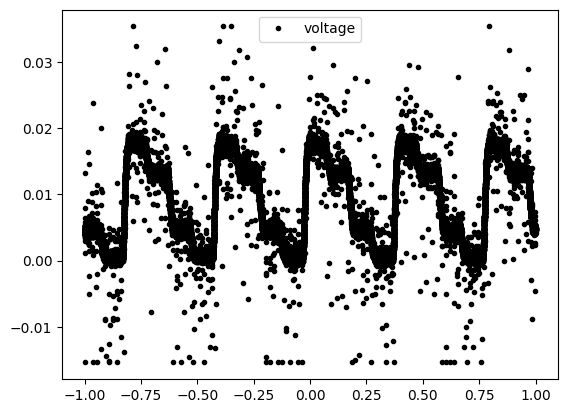

In [70]:
time = data['Time']
voltage = data['Voltage']
current = data['Current']
plt.plot(time, voltage,'.k', label='voltage')
plt.legend()
plt.show()

In [71]:
def EstimateRes(voltage, current):
    # example of least-squares estimator
    # try your own estimator
    return np.sum(voltage * current) / np.sum(current * current)

In [72]:
def ProcessDataset(dataDir):
    dataDir = Path(dataDir)
    results = []

    for sample_dir in sorted(dataDir.glob("sample*")):
        for csv_file in sorted(sample_dir.glob("experiment*.csv")):
            #print(csv_file)
            df = ReadExperiment(csv_file)

            resistance = EstimateRes(
                df["Voltage"].to_numpy(),
                df["Current"].to_numpy()
            )

            results.append({
                "sample": sample_dir.name,
                "experiment": csv_file.stem,
                "resistance_ohm": resistance,
                "temperature_mean_celsius": df["Temperature"].mean()
            })

    return pd.DataFrame(results)

In [75]:
results = ProcessDataset("../data")
results

,sample,experiment,resistance_ohm,temperature_mean_celsius
0,sample0,experiment0,0.000450,25.870881
1,sample0,experiment1,0.000439,25.817065
2,sample0,experiment2,0.000433,25.696297
3,sample0,experiment3,0.000436,25.975361
4,sample0,experiment4,0.000435,26.012913
...,...,...,...,...
95,sample9,experiment5,0.000493,27.040197
96,sample9,experiment6,0.000516,27.138345
97,sample9,experiment7,0.000502,27.111845
98,sample9,experiment8,0.000509,27.201209
